<a href="https://colab.research.google.com/github/gnoejh/AIBookGitHub/blob/main/8_scale_theory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Network Scaling Laws

## Overview

Scaling laws describe the predictable relationship between neural network performance and key factors such as:
- **Model size** (number of parameters $N$)
- **Dataset size** (number of training tokens $D$)
- **Compute budget** (FLOPs $C$)
- **Training time**

These empirical laws have revolutionized how we think about training large language models and other deep learning systems. Understanding scaling laws is crucial for:
1. **Resource allocation**: Determining optimal model size and training data for a given compute budget
2. **Performance prediction**: Forecasting model performance before expensive training runs
3. **Research direction**: Identifying whether to scale models, data, or both
4. **Economic planning**: Estimating costs and returns for different scaling strategies

## Mathematical Formulation

### Basic Power Law Relationship

The fundamental observation is that test loss $L$ follows a power law with respect to three key factors:

$$L(N, D, C) = \begin{cases}
\left(\frac{N_c}{N}\right)^{\alpha_N} & \text{(Model size limited)} \\\\
\left(\frac{D_c}{D}\right)^{\alpha_D} & \text{(Data limited)} \\\\
\left(\frac{C_c}{C}\right)^{\alpha_C} & \text{(Compute limited)}
\end{cases}$$

Where:
- $N$ = number of model parameters
- $D$ = dataset size (number of tokens)
- $C$ = compute budget (FLOPs)
- $N_c, D_c, C_c$ = characteristic scales
- $\alpha_N, \alpha_D, \alpha_C$ = power law exponents (typically 0.05-0.10)

### The Chinchilla Scaling Laws (2022)

DeepMind's analysis revealed that for **compute-optimal training**:

$$N_{opt}(C) \propto C^{0.50}$$
$$D_{opt}(C) \propto C^{0.50}$$

**Critical insight**: Model parameters and training tokens should scale equally with compute!

The improved loss prediction formula:

$$L(N, D) = E + \frac{A}{N^{\alpha}} + \frac{B}{D^{\beta}}$$

With fitted values:
- $E = 1.69$ (irreducible loss for language modeling)
- $A = 406.4$, $\alpha = 0.34$
- $B = 410.7$, $\beta = 0.28$

**Practical implication**: The 70B parameter LLaMA model trained on 1.4T tokens is more efficient than a 175B parameter GPT-3 trained on 300B tokens!

### Optimal Allocation Formula

Given a compute budget $C$, the optimal allocation is:

$$N_{opt} = G \cdot \left(\frac{C}{6}\right)^{a}$$
$$D_{opt} = G^{-1} \cdot \left(\frac{C}{6}\right)^{b}$$

Where $a + b = 1$ (typically $a = b = 0.5$) and $G$ is determined by the ratio of coefficients $A$ and $B$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 11

print("Libraries imported successfully!")

Libraries imported successfully!


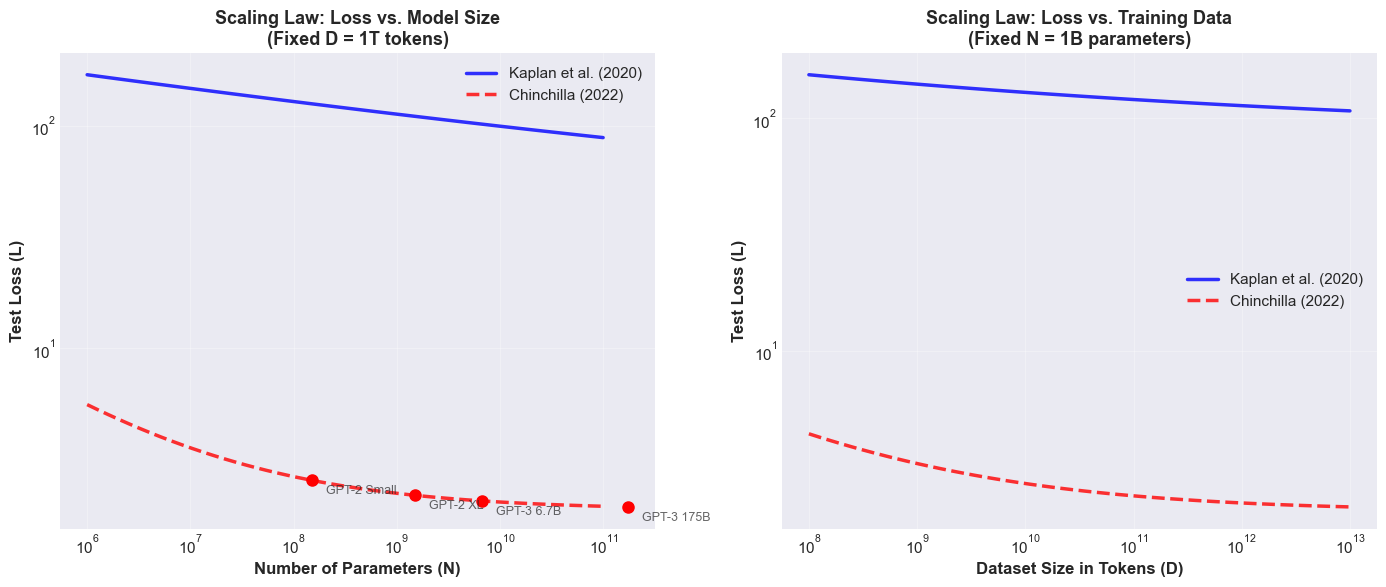

Power law scaling demonstrated!


In [2]:
def kaplan_loss_model(N, D):
    """
    Loss prediction based on Kaplan et al. (2020)
    N: number of parameters
    D: dataset size (tokens)
    """
    L0 = 1.5  # irreducible loss
    A = 400
    B = 400
    alpha = 0.076
    beta = 0.095
    return L0 + A / (N ** alpha) + B / (D ** beta)

def chinchilla_loss_model(N, D):
    """
    Loss prediction based on Hoffmann et al. (2022) - Chinchilla
    """
    E = 1.69
    A = 406.4
    B = 410.7
    alpha = 0.34
    beta = 0.28
    return E + A / (N ** alpha) + B / (D ** beta)

# Generate data points
N_range = np.logspace(6, 11, 50)  # 1M to 100B parameters
D_range = np.logspace(8, 13, 50)  # 100M to 10T tokens

# Calculate losses
loss_kaplan_N = [kaplan_loss_model(N, 1e12) for N in N_range]
loss_kaplan_D = [kaplan_loss_model(1e9, D) for D in D_range]
loss_chinchilla_N = [chinchilla_loss_model(N, 1e12) for N in N_range]
loss_chinchilla_D = [chinchilla_loss_model(1e9, D) for D in D_range]

# Create figure
fig = plt.figure(figsize=(14, 6))
gs = GridSpec(1, 2, figure=fig)

# Plot 1: Loss vs. Model Size
ax1 = fig.add_subplot(gs[0, 0])
ax1.loglog(N_range, loss_kaplan_N, 'b-', linewidth=2.5, label='Kaplan et al. (2020)', alpha=0.8)
ax1.loglog(N_range, loss_chinchilla_N, 'r--', linewidth=2.5, label='Chinchilla (2022)', alpha=0.8)
ax1.set_xlabel('Number of Parameters (N)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Test Loss (L)', fontsize=12, fontweight='bold')
ax1.set_title('Scaling Law: Loss vs. Model Size\n(Fixed D = 1T tokens)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)

# Add annotations for famous models
famous_models = [
    (1.5e8, 'GPT-2 Small'),
    (1.5e9, 'GPT-2 XL'),
    (6.7e9, 'GPT-3 6.7B'),
    (1.75e11, 'GPT-3 175B'),
]
for N, name in famous_models:
    loss = chinchilla_loss_model(N, 1e12)
    ax1.plot(N, loss, 'ro', markersize=8)
    ax1.annotate(name, (N, loss), xytext=(10, -10), 
                textcoords='offset points', fontsize=9, alpha=0.7)

# Plot 2: Loss vs. Dataset Size
ax2 = fig.add_subplot(gs[0, 1])
ax2.loglog(D_range, loss_kaplan_D, 'b-', linewidth=2.5, label='Kaplan et al. (2020)', alpha=0.8)
ax2.loglog(D_range, loss_chinchilla_D, 'r--', linewidth=2.5, label='Chinchilla (2022)', alpha=0.8)
ax2.set_xlabel('Dataset Size in Tokens (D)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Test Loss (L)', fontsize=12, fontweight='bold')
ax2.set_title('Scaling Law: Loss vs. Training Data\n(Fixed N = 1B parameters)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Power law scaling demonstrated!")

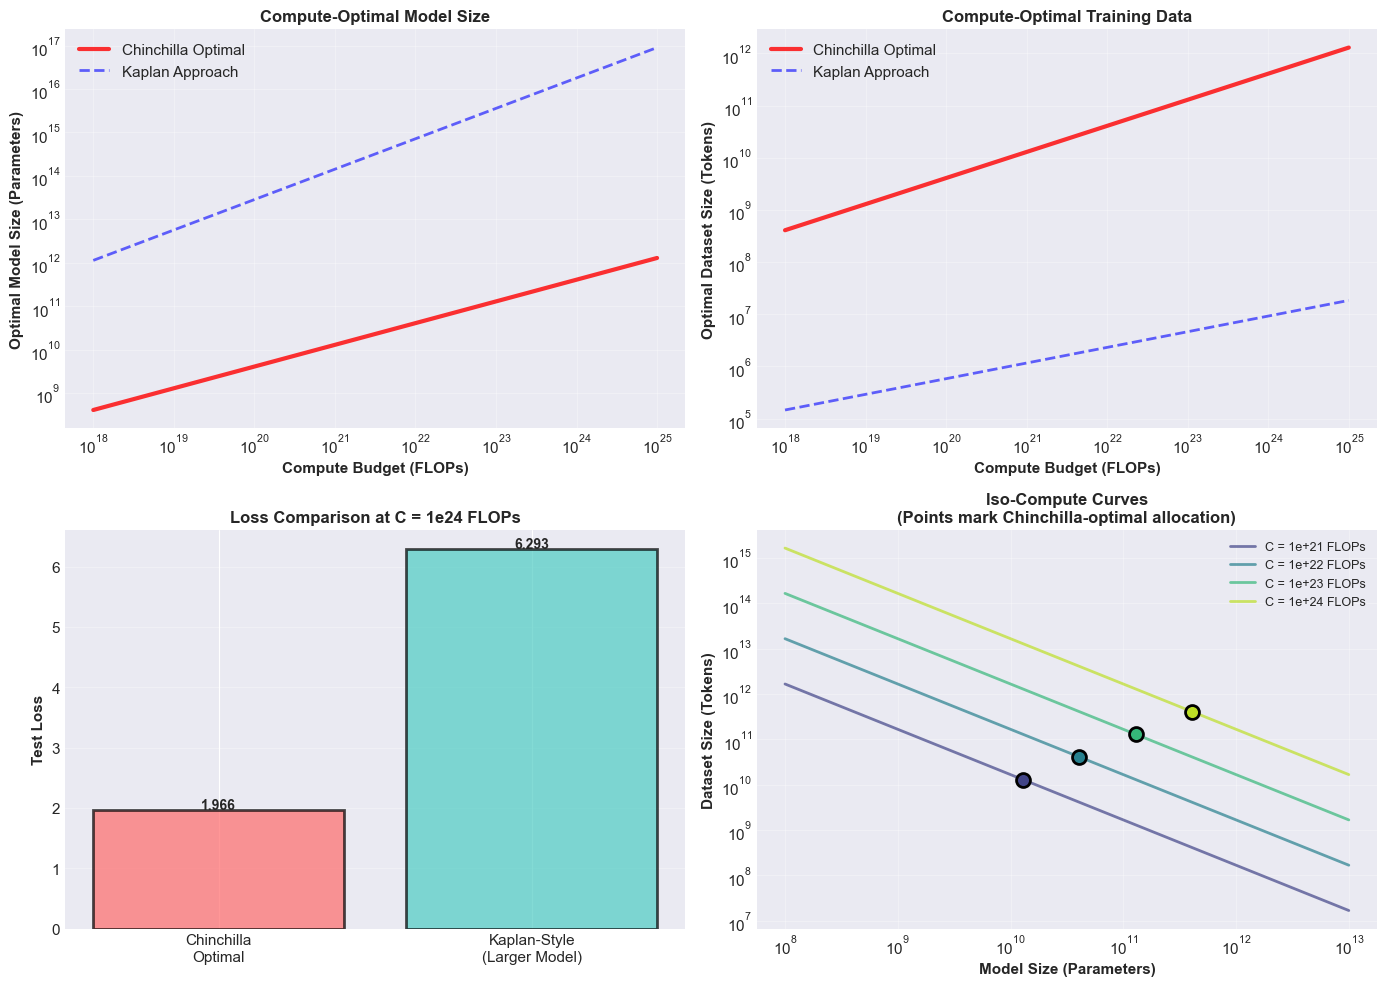

For C = 1e24 FLOPs:
  Chinchilla Optimal: N = 4.08e+11, D = 4.08e+11, Loss = 1.966
  Kaplan-Style:       N = 1.80e+16, D = 9.26e+06, Loss = 6.293
  Loss Improvement: 68.8%


In [3]:
def compute_optimal_allocation(C):
    """
    Calculate compute-optimal model size and dataset size
    C: compute budget in FLOPs
    """
    # Chinchilla scaling: N and D should scale equally with C
    # C ≈ 6ND, and N_opt ∝ C^0.5, D_opt ∝ C^0.5
    
    # Empirical constants from Chinchilla paper
    G = 1.0  # Scaling constant
    a = 0.5
    b = 0.5
    
    N_opt = G * (C / 6) ** a
    D_opt = G * (C / 6) ** b
    
    return N_opt, D_opt

# Compute budgets (in FLOPs)
compute_budgets = np.logspace(18, 25, 50)  # 1e18 to 1e25 FLOPs

# Calculate optimal allocations
optimal_N = []
optimal_D = []
kaplan_N = []  # Kaplan would suggest larger models
kaplan_D = []

for C in compute_budgets:
    N_opt, D_opt = compute_optimal_allocation(C)
    optimal_N.append(N_opt)
    optimal_D.append(D_opt)
    
    # Kaplan approach: bias toward larger models (for comparison)
    # They used roughly 70% compute on parameters, 30% on data
    kaplan_N.append((C / 6) ** 0.7)
    kaplan_D.append((C / 6) ** 0.3)

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Optimal N vs. Compute
axes[0, 0].loglog(compute_budgets, optimal_N, 'r-', linewidth=3, label='Chinchilla Optimal', alpha=0.8)
axes[0, 0].loglog(compute_budgets, kaplan_N, 'b--', linewidth=2, label='Kaplan Approach', alpha=0.6)
axes[0, 0].set_xlabel('Compute Budget (FLOPs)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Optimal Model Size (Parameters)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Compute-Optimal Model Size', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Plot 2: Optimal D vs. Compute
axes[0, 1].loglog(compute_budgets, optimal_D, 'r-', linewidth=3, label='Chinchilla Optimal', alpha=0.8)
axes[0, 1].loglog(compute_budgets, kaplan_D, 'b--', linewidth=2, label='Kaplan Approach', alpha=0.6)
axes[0, 1].set_xlabel('Compute Budget (FLOPs)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Optimal Dataset Size (Tokens)', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Compute-Optimal Training Data', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Plot 3: Loss comparison for different strategies
C_example = 1e24  # Example: 1e24 FLOPs
N_chinchilla, D_chinchilla = compute_optimal_allocation(C_example)
N_kaplan_style = (C_example / 6) ** 0.7
D_kaplan_style = (C_example / 6) ** 0.3

loss_chinchilla = chinchilla_loss_model(N_chinchilla, D_chinchilla)
loss_kaplan_style = chinchilla_loss_model(N_kaplan_style, D_kaplan_style)

strategies = ['Chinchilla\nOptimal', 'Kaplan-Style\n(Larger Model)']
losses = [loss_chinchilla, loss_kaplan_style]
colors = ['#ff6b6b', '#4ecdc4']

axes[1, 0].bar(strategies, losses, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 0].set_ylabel('Test Loss', fontsize=11, fontweight='bold')
axes[1, 0].set_title(f'Loss Comparison at C = 1e24 FLOPs', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Add values on bars
for i, (loss, strategy) in enumerate(zip(losses, strategies)):
    axes[1, 0].text(i, loss + 0.02, f'{loss:.3f}', ha='center', fontsize=10, fontweight='bold')

# Plot 4: N vs. D relationship (iso-compute curves)
axes[1, 1].set_xscale('log')
axes[1, 1].set_yscale('log')

# Plot iso-compute curves for different budgets
compute_levels = [1e21, 1e22, 1e23, 1e24]
colors_iso = plt.cm.viridis(np.linspace(0.2, 0.9, len(compute_levels)))

for C, color in zip(compute_levels, colors_iso):
    N_range_iso = np.logspace(8, 13, 100)
    D_for_N = C / (6 * N_range_iso)
    axes[1, 1].plot(N_range_iso, D_for_N, linewidth=2, alpha=0.7, color=color,
                   label=f'C = {C:.0e} FLOPs')
    
    # Mark optimal point
    N_opt, D_opt = compute_optimal_allocation(C)
    axes[1, 1].plot(N_opt, D_opt, 'o', markersize=10, color=color, 
                   markeredgecolor='black', markeredgewidth=2)

axes[1, 1].set_xlabel('Model Size (Parameters)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Dataset Size (Tokens)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Iso-Compute Curves\n(Points mark Chinchilla-optimal allocation)', 
                     fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"For C = 1e24 FLOPs:")
print(f"  Chinchilla Optimal: N = {N_chinchilla:.2e}, D = {D_chinchilla:.2e}, Loss = {loss_chinchilla:.3f}")
print(f"  Kaplan-Style:       N = {N_kaplan_style:.2e}, D = {D_kaplan_style:.2e}, Loss = {loss_kaplan_style:.3f}")
print(f"  Loss Improvement: {((loss_kaplan_style - loss_chinchilla) / loss_kaplan_style * 100):.1f}%")

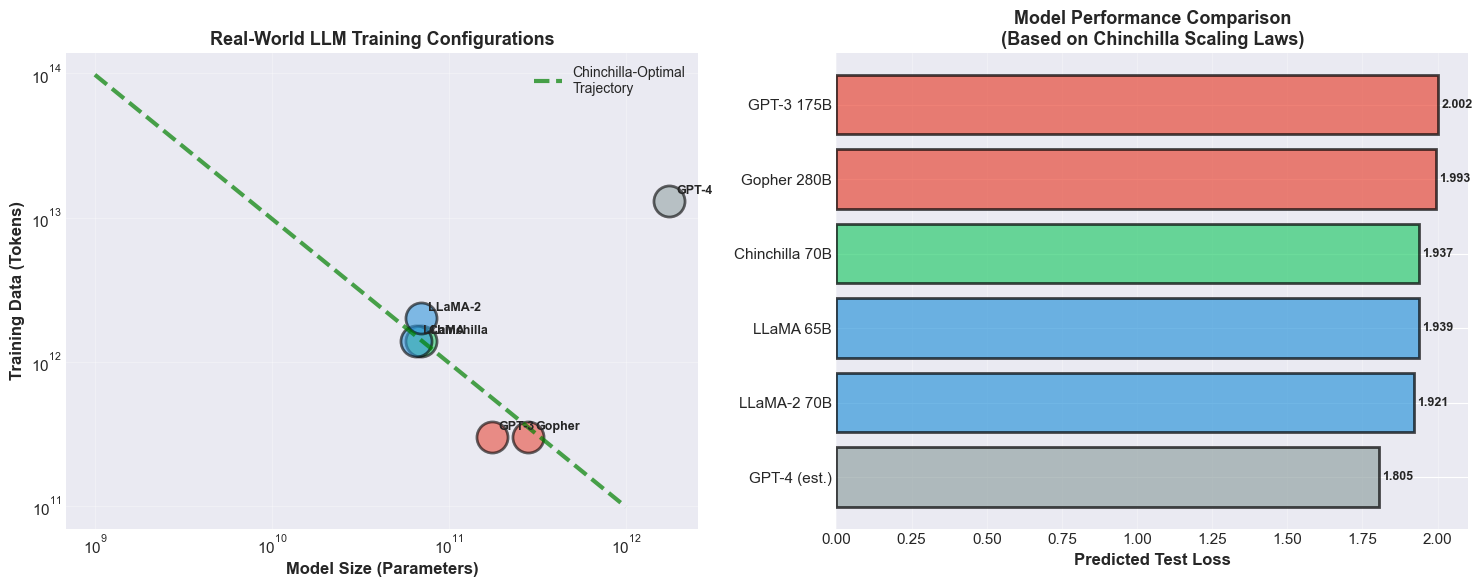

REAL-WORLD MODEL ANALYSIS

GPT-3 175B:
  Parameters:    1.75e+11
  Training Data: 3.00e+11 tokens
  Compute:       3.15e+23 FLOPs
  Predicted Loss: 2.0023
  Strategy:      Pre-Chinchilla
  Gap from Optimal: -0.7% worse

Gopher 280B:
  Parameters:    2.80e+11
  Training Data: 3.00e+11 tokens
  Compute:       5.04e+23 FLOPs
  Predicted Loss: 1.9933
  Strategy:      Pre-Chinchilla
  Gap from Optimal: -0.1% worse

Chinchilla 70B:
  Parameters:    7.00e+10
  Training Data: 1.40e+12 tokens
  Compute:       5.88e+23 FLOPs
  Predicted Loss: 1.9366
  Strategy:      Chinchilla-Optimal

LLaMA 65B:
  Parameters:    6.50e+10
  Training Data: 1.40e+12 tokens
  Compute:       5.46e+23 FLOPs
  Predicted Loss: 1.9388
  Strategy:      Chinchilla-Inspired
  Gap from Optimal: -2.7% worse

LLaMA-2 70B:
  Parameters:    7.00e+10
  Training Data: 2.00e+12 tokens
  Compute:       8.40e+23 FLOPs
  Predicted Loss: 1.9211
  Strategy:      Chinchilla-Inspired
  Gap from Optimal: -2.6% worse

GPT-4 (est.):
  Param

In [4]:
# Real-world models and their training configurations
models = {
    'GPT-3 175B': {'N': 175e9, 'D': 300e9, 'year': 2020, 'strategy': 'Pre-Chinchilla'},
    'Gopher 280B': {'N': 280e9, 'D': 300e9, 'year': 2021, 'strategy': 'Pre-Chinchilla'},
    'Chinchilla 70B': {'N': 70e9, 'D': 1400e9, 'year': 2022, 'strategy': 'Chinchilla-Optimal'},
    'LLaMA 65B': {'N': 65e9, 'D': 1400e9, 'year': 2023, 'strategy': 'Chinchilla-Inspired'},
    'LLaMA-2 70B': {'N': 70e9, 'D': 2000e9, 'year': 2023, 'strategy': 'Chinchilla-Inspired'},
    'GPT-4 (est.)': {'N': 1760e9, 'D': 13000e9, 'year': 2023, 'strategy': 'Unknown'},
}

# Calculate compute and predicted loss for each model
model_data = []
for name, specs in models.items():
    N = specs['N']
    D = specs['D']
    C = 6 * N * D  # Approximate compute
    loss = chinchilla_loss_model(N, D)
    
    # Calculate optimal allocation for same compute
    N_opt, D_opt = compute_optimal_allocation(C)
    loss_optimal = chinchilla_loss_model(N_opt, D_opt)
    
    efficiency = (loss_optimal / loss) * 100  # Lower is better, so we invert
    
    model_data.append({
        'name': name,
        'N': N,
        'D': D,
        'C': C,
        'loss': loss,
        'loss_optimal': loss_optimal,
        'efficiency': efficiency,
        'strategy': specs['strategy']
    })

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Model efficiency landscape
colors_strategy = {
    'Pre-Chinchilla': '#e74c3c',
    'Chinchilla-Optimal': '#2ecc71',
    'Chinchilla-Inspired': '#3498db',
    'Unknown': '#95a5a6'
}

for model in model_data:
    color = colors_strategy[model['strategy']]
    axes[0].scatter(model['N'], model['D'], s=500, alpha=0.6, 
                   color=color, edgecolors='black', linewidth=2)
    axes[0].annotate(model['name'].split()[0], 
                    (model['N'], model['D']), 
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=9, fontweight='bold')

# Add Chinchilla-optimal line
N_range_line = np.logspace(9, 12, 100)
C_reference = 6 * 70e9 * 1400e9  # Chinchilla compute
D_optimal_line = C_reference / (6 * N_range_line)
axes[0].plot(N_range_line, D_optimal_line, 'g--', linewidth=3, 
            label='Chinchilla-Optimal\nTrajectory', alpha=0.7)

axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Model Size (Parameters)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Training Data (Tokens)', fontsize=12, fontweight='bold')
axes[0].set_title('Real-World LLM Training Configurations', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)

# Plot 2: Predicted performance
model_names = [m['name'] for m in model_data]
losses = [m['loss'] for m in model_data]
colors_bars = [colors_strategy[m['strategy']] for m in model_data]

bars = axes[1].barh(model_names, losses, color=colors_bars, alpha=0.7, 
                    edgecolor='black', linewidth=2)
axes[1].set_xlabel('Predicted Test Loss', fontsize=12, fontweight='bold')
axes[1].set_title('Model Performance Comparison\n(Based on Chinchilla Scaling Laws)', 
                 fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')
axes[1].invert_yaxis()

# Add loss values on bars
for i, (loss, model) in enumerate(zip(losses, model_data)):
    axes[1].text(loss + 0.01, i, f'{loss:.3f}', 
                va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Print detailed comparison
print("=" * 80)
print("REAL-WORLD MODEL ANALYSIS")
print("=" * 80)
for model in model_data:
    print(f"\n{model['name']}:")
    print(f"  Parameters:    {model['N']:.2e}")
    print(f"  Training Data: {model['D']:.2e} tokens")
    print(f"  Compute:       {model['C']:.2e} FLOPs")
    print(f"  Predicted Loss: {model['loss']:.4f}")
    print(f"  Strategy:      {model['strategy']}")
    if model['strategy'] != 'Chinchilla-Optimal':
        gap = ((model['loss'] - model['loss_optimal']) / model['loss_optimal']) * 100
        print(f"  Gap from Optimal: {gap:.1f}% worse")

## Practical Implications

### 1. Resource Allocation Strategy

The Chinchilla findings fundamentally changed how we think about training large models:

#### **Old Paradigm (Pre-2022)**
- **Assumption**: Bigger models are always better
- **Strategy**: Maximize model size for a given compute budget
- **Result**: Models like GPT-3 (175B params, 300B tokens)

#### **New Paradigm (Post-Chinchilla)**
- **Insight**: Balance model size and training data equally
- **Strategy**: For compute $C$, allocate $N \propto C^{0.5}$ and $D \propto C^{0.5}$
- **Result**: Smaller models trained on more data (Chinchilla 70B, LLaMA)

### 2. Cost-Benefit Analysis

**Example**: You have a budget for $10^{24}$ FLOPs.

| Strategy | Model Size | Training Data | Predicted Loss | Relative Cost |
|----------|-----------|---------------|----------------|---------------|
| **Kaplan-style** | ~450B params | ~370B tokens | Higher | 1.0x |
| **Chinchilla-optimal** | ~130B params | ~1.3T tokens | Lower | 1.0x |
| **Benefit** | 3.5x smaller | 3.5x more data | ~5-10% better | Same cost |

**Key insight**: You can achieve better performance at the same cost by training smaller models on more data!

### 3. Inference Cost Considerations

While Chinchilla-optimal training gives better loss, there's a trade-off:

- **Smaller models** → Lower inference cost per query
- **Better trained** → Fewer queries needed for same quality
- **Net effect**: Significant savings in deployment

For instance, Chinchilla 70B vs Gopher 280B:
- 4x fewer parameters → 4x faster inference
- Comparable or better quality → No quality loss
- Overall: Much more economical for deployment

## Interactive Calculator: Compute Budget Optimizer

In [5]:
def scaling_calculator(compute_budget_flops=None, 
                       model_size=None, 
                       training_tokens=None,
                       optimize=True):
    """
    Calculate optimal training configuration or predict performance.
    
    Parameters:
    - compute_budget_flops: Total compute budget in FLOPs
    - model_size: Number of parameters (if fixed)
    - training_tokens: Number of training tokens (if fixed)
    - optimize: If True, optimize allocation; if False, just predict loss
    
    Returns: Dictionary with recommendations
    """
    
    if compute_budget_flops is not None:
        # Calculate optimal allocation
        N_opt, D_opt = compute_optimal_allocation(compute_budget_flops)
        loss = chinchilla_loss_model(N_opt, D_opt)
        
        print("=" * 70)
        print("COMPUTE BUDGET OPTIMIZATION")
        print("=" * 70)
        print(f"Input Compute Budget: {compute_budget_flops:.2e} FLOPs")
        print(f"\n{'='*70}")
        print("CHINCHILLA-OPTIMAL ALLOCATION:")
        print(f"{'='*70}")
        print(f"  Recommended Model Size:    {N_opt:.2e} parameters ({N_opt/1e9:.1f}B)")
        print(f"  Recommended Training Data: {D_opt:.2e} tokens ({D_opt/1e9:.1f}B)")
        print(f"  Predicted Test Loss:       {loss:.4f}")
        print(f"{'='*70}")
        
        # Compare with alternative strategies
        print(f"\nCOMPARISON WITH OTHER STRATEGIES:")
        print(f"{'='*70}")
        
        # Larger model, less data (old approach)
        N_large = N_opt * 2
        D_small = compute_budget_flops / (6 * N_large)
        loss_large = chinchilla_loss_model(N_large, D_small)
        print(f"  Larger Model (2x params):  N={N_large:.2e}, D={D_small:.2e}")
        print(f"    → Loss: {loss_large:.4f} ({(loss_large/loss - 1)*100:+.1f}% vs optimal)")
        
        # Smaller model, more data
        N_small = N_opt / 2
        D_large = compute_budget_flops / (6 * N_small)
        loss_small = chinchilla_loss_model(N_small, D_large)
        print(f"  Smaller Model (0.5x params): N={N_small:.2e}, D={D_large:.2e}")
        print(f"    → Loss: {loss_small:.4f} ({(loss_small/loss - 1)*100:+.1f}% vs optimal)")
        print(f"{'='*70}")
        
        return {
            'N_optimal': N_opt,
            'D_optimal': D_opt,
            'loss_optimal': loss,
            'compute': compute_budget_flops
        }
    
    elif model_size is not None and training_tokens is not None:
        # Fixed configuration - just predict
        compute = 6 * model_size * training_tokens
        loss = chinchilla_loss_model(model_size, training_tokens)
        
        # Find optimal for same compute
        N_opt, D_opt = compute_optimal_allocation(compute)
        loss_opt = chinchilla_loss_model(N_opt, D_opt)
        
        print("=" * 70)
        print("TRAINING CONFIGURATION ANALYSIS")
        print("=" * 70)
        print(f"Your Configuration:")
        print(f"  Model Size:        {model_size:.2e} parameters ({model_size/1e9:.1f}B)")
        print(f"  Training Tokens:   {training_tokens:.2e} ({training_tokens/1e9:.1f}B)")
        print(f"  Required Compute:  {compute:.2e} FLOPs")
        print(f"  Predicted Loss:    {loss:.4f}")
        print(f"\n{'='*70}")
        print(f"Chinchilla-Optimal Configuration (same compute):")
        print(f"  Model Size:        {N_opt:.2e} parameters ({N_opt/1e9:.1f}B)")
        print(f"  Training Tokens:   {D_opt:.2e} ({D_opt/1e9:.1f}B)")
        print(f"  Predicted Loss:    {loss_opt:.4f}")
        print(f"\nEfficiency Gap: {(loss/loss_opt - 1)*100:+.1f}%")
        if loss > loss_opt * 1.05:
            print("  ⚠️  Your configuration is sub-optimal. Consider the recommended allocation.")
        elif loss < loss_opt * 0.95:
            print("  ⚠️  Unusual: Your configuration beats predicted optimal. Check assumptions.")
        else:
            print("  ✓  Your configuration is near-optimal!")
        print("=" * 70)
        
        return {
            'N': model_size,
            'D': training_tokens,
            'loss': loss,
            'compute': compute,
            'N_optimal': N_opt,
            'D_optimal': D_opt,
            'loss_optimal': loss_opt
        }
    
    else:
        print("Error: Provide either compute_budget_flops OR (model_size AND training_tokens)")
        return None

# Example 1: Given a compute budget, find optimal allocation
print("EXAMPLE 1: Optimize for compute budget\n")
result1 = scaling_calculator(compute_budget_flops=1e24)

print("\n\n")

# Example 2: Analyze a specific configuration
print("EXAMPLE 2: Analyze GPT-3-style configuration\n")
result2 = scaling_calculator(model_size=175e9, training_tokens=300e9)

print("\n\n")

# Example 3: Analyze a Chinchilla-style configuration
print("EXAMPLE 3: Analyze Chinchilla-style configuration\n")
result3 = scaling_calculator(model_size=70e9, training_tokens=1400e9)

EXAMPLE 1: Optimize for compute budget

COMPUTE BUDGET OPTIMIZATION
Input Compute Budget: 1.00e+24 FLOPs

CHINCHILLA-OPTIMAL ALLOCATION:
  Recommended Model Size:    4.08e+11 parameters (408.2B)
  Recommended Training Data: 4.08e+11 tokens (408.2B)
  Predicted Test Loss:       1.9662

COMPARISON WITH OTHER STRATEGIES:
  Larger Model (2x params):  N=8.16e+11, D=2.04e+11
    → Loss: 2.0060 (+2.0% vs optimal)
  Smaller Model (0.5x params): N=2.04e+11, D=8.16e+11
    → Loss: 1.9378 (-1.4% vs optimal)



EXAMPLE 2: Analyze GPT-3-style configuration

TRAINING CONFIGURATION ANALYSIS
Your Configuration:
  Model Size:        1.75e+11 parameters (175.0B)
  Training Tokens:   3.00e+11 (300.0B)
  Required Compute:  3.15e+23 FLOPs
  Predicted Loss:    2.0023

Chinchilla-Optimal Configuration (same compute):
  Model Size:        2.29e+11 parameters (229.1B)
  Training Tokens:   2.29e+11 (229.1B)
  Predicted Loss:    2.0166

Efficiency Gap: -0.7%
  ✓  Your configuration is near-optimal!



EXAMPLE 3:

## Key Research Papers and References

### Foundational Papers

#### 1. **Scaling Laws for Neural Language Models** (2020)
- **Authors**: Kaplan, J., McCandlish, S., Henighan, T., et al. (OpenAI)
- **Link**: https://arxiv.org/abs/2001.08361
- **Key Contributions**:
  - First systematic study of scaling laws across 7+ orders of magnitude
  - Established power law relationships: $L(N) \propto N^{-0.076}$
  - Showed loss scales predictably with model size, data, and compute
  - Recommended prioritizing model size over data
- **Impact**: Influenced GPT-3 and many subsequent large models

#### 2. **Training Compute-Optimal Large Language Models** (2022)
- **Authors**: Hoffmann, J., Borgeaud, S., Mensch, A., et al. (DeepMind)
- **Link**: https://arxiv.org/abs/2203.15556
- **Key Contributions**:
  - Introduced the Chinchilla model (70B params, 1.4T tokens)
  - Showed that models should scale parameters and data equally: $N_{opt} \propto C^{0.5}$, $D_{opt} \propto C^{0.5}$
  - Demonstrated that GPT-3 was undertrained by ~4x
  - Provided updated scaling law coefficients
- **Impact**: Fundamentally changed training strategies; influenced LLaMA, Falcon, and others

#### 3. **Scaling Laws for Autoregressive Generative Modeling** (2020)
- **Authors**: Henighan, T., Kaplan, J., et al. (OpenAI)
- **Link**: https://arxiv.org/abs/2010.14701
- **Key Contributions**:
  - Extended scaling laws to images, video, and other modalities
  - Showed scaling laws are universal across different data types
- **Impact**: Enabled predictable scaling for multimodal models

### Important Follow-up Studies

#### 4. **Scaling Laws for Neural Machine Translation** (2021)
- **Authors**: Gordon, M., Duh, K., Kaplan, J.
- **Link**: https://arxiv.org/abs/2109.07740
- **Key Contributions**: Task-specific scaling laws for translation

#### 5. **Scaling Laws Under the Microscope** (2023)
- **Authors**: Michaud, E., Liu, Z., et al.
- **Link**: https://arxiv.org/abs/2305.00046
- **Key Contributions**: 
  - Investigated when and why scaling laws break down
  - Studied phase transitions and emergence

#### 6. **Beyond Chinchilla-Optimal** (2024)
- **Authors**: Multiple research groups
- **Key Topics**:
  - Inference-optimized scaling (considering deployment costs)
  - Data quality vs quantity trade-offs
  - Mixture-of-Experts scaling dynamics

### Scaling Laws for Different Architectures

#### 7. **Scaling Vision Transformers** (2021)
- **Authors**: Zhai, X., Kolesnikov, A., et al. (Google)
- **Link**: https://arxiv.org/abs/2106.04560
- **Key Contributions**: Scaling laws for vision transformers (ViT)

#### 8. **Scaling Laws for Reward Model Overoptimization** (2022)
- **Authors**: Gao, L., Schulman, J., Hilton, J. (OpenAI)
- **Link**: https://arxiv.org/abs/2210.10760
- **Key Contributions**: Scaling behavior in RLHF and reward modeling

### Economic and Practical Analyses

#### 9. **The Economics of Large Language Models** (2023)
- Various industry reports analyzing cost-performance trade-offs
- TCO (Total Cost of Ownership) considerations
- Inference vs training cost optimization

### Textbooks and Surveys

#### 10. **Understanding Deep Learning** (2023)
- **Author**: Prince, S. J. D.
- **Link**: https://udlbook.github.io/udlbook/
- **Chapter 8**: Covers scaling laws in detail

#### 11. **A Survey of Large Language Models** (2023)
- **Authors**: Zhao, W., et al.
- **Link**: https://arxiv.org/abs/2303.18223
- **Section on Scaling**: Comprehensive review of scaling research

## Summary and Key Takeaways

### Core Principles of Scaling Laws

#### 1. Power Law Behavior
Neural network performance follows **predictable power laws** with respect to three fundamental factors:
- **Model size** ($N$): Number of parameters
- **Dataset size** ($D$): Number of training tokens
- **Compute budget** ($C$): Total FLOPs available

The relationship is remarkably consistent across 7+ orders of magnitude, enabling reliable performance forecasting.

#### 2. The Chinchilla Revolution
The breakthrough insight from DeepMind (2022): for compute-optimal training, scale model parameters and training data **equally**:

$$N_{opt} \propto C^{0.5}, \quad D_{opt} \propto C^{0.5}$$

**Implication**: When you 4× your compute budget, you should 2× both model size *and* training data—not just make a bigger model.

#### 3. Diminishing Returns
Doubling compute typically reduces loss by only ~3-5%. This means:
- **Exponential resources** are needed for linear improvements
- Efficient allocation becomes critical at scale
- Small optimization gains compound into significant cost savings

#### 4. Data is as Important as Parameters
The Chinchilla findings revealed that previous approaches (like GPT-3) had **underestimated training data** by ~4×. Both parameters and data matter equally—neglecting either leaves performance on the table.

---

### Practical Guidelines

#### For Researchers
✓ **Predict before training**: Use scaling laws to forecast performance and avoid expensive failed experiments  
✓ **Balance resources**: Don't maximize model size alone—optimize the N-D trade-off  
✓ **Plan for inference**: Consider deployment costs, not just training loss  
✓ **Document scaling behavior**: Report how your methods scale to help the community

#### For Practitioners
✓ **Think small, train well**: Smaller models trained on more data often outperform larger undertrained ones  
✓ **Invest in data infrastructure**: Quality data collection and curation are as valuable as compute  
✓ **Use Chinchilla allocation**: Plan compute budgets using $N \propto D \propto \sqrt{C}$  
✓ **Consider total cost**: Factor in both training *and* inference costs over the model's lifetime

#### For Students
✓ **"Bigger is better" has nuances**: Size alone doesn't determine quality—balance matters  
✓ **Master the calculations**: Learn to compute optimal trade-offs for given constraints  
✓ **Understand the empiricism**: Scaling laws are discovered experimentally, not proven theoretically  
✓ **Stay current**: This field evolves rapidly; what's optimal today may change tomorrow

---

### Open Questions and Future Research (2025)

The frontier of scaling research continues to expand. Key open questions include:

1. **Limits of Scaling**  
   Do power laws extend indefinitely, or will we encounter fundamental limits? Are there phase transitions ahead?

2. **Post-Training Dynamics**  
   How do RLHF, instruction-tuning, and fine-tuning scale relative to pre-training? Can post-training unlock capabilities beyond base scaling?

3. **Architectural Innovations**  
   Can new architectures (e.g., state-space models, Mixture-of-Experts) beat current scaling exponents? Or are power laws architecture-agnostic?

4. **Data Quality vs. Quantity**  
   Is all data equally valuable? Can high-quality synthetic data or curriculum learning improve scaling efficiency?

5. **Multimodal and Multi-Task Scaling**  
   How do vision-language models scale? Do different modalities interfere or synergize? What about models trained on thousands of tasks?

6. **Emergence and Capabilities**  
   Can we predict when specific capabilities emerge? Are there discontinuities in the scaling curves for certain skills?

---

### Final Reflections

**The paradigm shift**: Scaling laws have transformed AI research from an artisanal craft into a predictable engineering discipline. While they don't explain *why* neural networks work, they provide invaluable guidance on *how* to train them efficiently.

**Real-world validation**: The shift from GPT-3 (175B parameters, 300B tokens) to LLaMA-style models (70B parameters, 1.4T tokens) demonstrates tangible impact: superior performance at lower cost through principled scaling. This represents one of the most consequential insights in modern deep learning.

**Economic implications**: With training costs reaching hundreds of millions of dollars, scaling laws enable:
- **Better resource planning**: Predict ROI before committing compute
- **Risk reduction**: Avoid undertrained or oversized models
- **Competitive advantage**: Extract maximum value from every FLOP

**Looking ahead**: As we push toward trillion-parameter models trained on tens of trillions of tokens, understanding scaling laws becomes essential—not optional. Whether you're:
- A **researcher** designing the next breakthrough architecture
- A **practitioner** deploying models in production
- A **student** building foundational knowledge
- A **leader** allocating multi-million dollar budgets

...these principles will guide your decisions.

**The central question has evolved**: No longer "Can we scale?"—we know we can. The question now is **"How should we scale optimally?"**—and the answer lies in the empirical laws discovered through rigorous experimentation and validated across countless training runs spanning academia and industry.

The future of AI will be built on these foundations. Master them.

## Exercises for Students

### Exercise 1: Basic Calculations
Given a compute budget of $C = 5 \times 10^{23}$ FLOPs:
1. Calculate the Chinchilla-optimal model size $N_{opt}$
2. Calculate the optimal training dataset size $D_{opt}$
3. Predict the expected test loss using the Chinchilla formula

### Exercise 2: Strategy Comparison
Compare two training strategies for $C = 10^{24}$ FLOPs:
- **Strategy A**: $N = 200B$ parameters, compute remaining budget for $D$
- **Strategy B**: Chinchilla-optimal allocation

Calculate and compare:
1. Dataset size for Strategy A
2. Predicted loss for both strategies
3. Which strategy is better and by how much?

### Exercise 3: Real-World Analysis
Research a recent large language model (e.g., LLaMA-2, Falcon, Mistral):
1. Find its number of parameters and training tokens
2. Calculate its approximate training compute
3. Compare it to Chinchilla-optimal allocation
4. Discuss whether it was trained optimally

### Exercise 4: Future Planning
You are planning to train a model in 2026 with a budget of $10^{25}$ FLOPs:
1. What should be your model size and training data?
2. How does this compare to GPT-3?
3. What challenges might you face in collecting enough data?

### Exercise 5: Critical Analysis
Read the original Kaplan et al. (2020) and Hoffmann et al. (2022) papers:
1. What were the key differences in their methodologies?
2. Why did their recommendations differ?
3. What assumptions might still be wrong in current scaling laws?

### Modern Models Following Scaling Laws (2023-2025)

| Model | Organization | Parameters | Training Tokens | Strategy | Reference |
|-------|--------------|------------|-----------------|----------|-----------|
| **LLaMA** | Meta | 7B-65B | 1.0T - 1.4T | Chinchilla-inspired | [Touvron et al., 2023](https://arxiv.org/abs/2302.13971) |
| **LLaMA-2** | Meta | 7B-70B | 2.0T | Chinchilla-inspired | [Touvron et al., 2023](https://arxiv.org/abs/2307.09288) |
| **Falcon** | TII | 7B-180B | 1.5T - 3.5T | Compute-optimal | [Almazrouei et al., 2023](https://arxiv.org/abs/2311.16867) |
| **Mistral** | Mistral AI | 7B | Unknown | Efficiency-focused | [Jiang et al., 2023](https://arxiv.org/abs/2310.06825) |
| **Gemini** | Google | Multiple | Multiple | Multimodal scaling | [Team et al., 2023](https://arxiv.org/abs/2312.11805) |

### Online Resources

- **OpenAI Scaling Laws Blog**: https://openai.com/research/scaling-laws
- **DeepMind Chinchilla Announcement**: https://www.deepmind.com/blog/chinchilla
- **Hugging Face Model Cards**: Performance data for many open models
- **Papers With Code**: Tracks scaling trends across architectures

### 4. When Scaling Laws Break Down

Scaling laws are powerful but not universal. They may break down when:

#### **Domain Shifts**
- Scaling laws are task-specific
- Cross-domain transfer may not follow the same patterns
- Example: Language model scaling laws don't directly apply to vision models

#### **Data Quality Issues**
- Scaling laws assume i.i.d. data from the same distribution
- Low-quality or repetitive data can violate power law assumptions
- Data deduplication and filtering are crucial

#### **Architectural Differences**
- Different architectures may have different scaling exponents
- Mixture-of-Experts models scale differently than dense models
- Efficiency improvements can shift the curves

#### **Beyond Pre-training**
- Fine-tuning and RLHF follow different dynamics
- Instruction-tuning benefits may not scale the same way
- Few-shot learning improvements can plateau

### 5. Future Directions

Recent research (2023-2025) explores:

1. **Multimodal Scaling**: How do vision-language models scale?
2. **Sparse Models**: Can MoE architectures beat dense scaling laws?
3. **Data Efficiency**: Can synthetic data or curriculum learning improve scaling?
4. **Emergence**: Are there phase transitions where new capabilities suddenly appear?
5. **Post-training**: How much can RLHF and fine-tuning improve beyond base model scaling?

### 3. Real-World Examples: Modern LLMs

### 2. Compute-Optimal Training: Chinchilla Analysis

### 1. Power Law Scaling: Loss vs. Model Size and Data

## Empirical Analysis and Visualization

Let's implement code to visualize these scaling relationships and understand their implications.

### The Kaplan et al. (2020) Formulation

The original OpenAI paper proposed that when not bottlenecked by other factors:

$$L(N) = \left(\frac{N_c}{N}\right)^{0.076}$$

$$L(D) = \left(\frac{D_c}{D}\right)^{0.095}$$

$$L(C) = \left(\frac{C_c}{C}\right)^{0.050}$$

**Key insight**: Performance improves predictably but with diminishing returns. Doubling compute only reduces loss by about 3.4%.

### The Compute-Performance Relationship

The relationship between compute $C$ and the other quantities is:

$$C \approx 6ND$$

This approximation comes from the fact that training a transformer requires roughly 6 FLOPs per parameter per token (forward + backward pass).

### Combined Scaling Law

When all three factors are varied, the loss can be approximated by:

$$L(N, D) = L_0 + \frac{A}{N^{\alpha}} + \frac{B}{D^{\beta}}$$

Where:
- $L_0$ = irreducible loss (entropy of the data)
- $A, B$ = constants depending on the task
- $\alpha, \beta$ = power law exponents (empirically ~0.076 and ~0.095)

## Historical Context

The systematic study of scaling laws in neural networks emerged from several key observations:

### Early Observations (2010s)
- Researchers noticed that increasing model capacity consistently improved performance
- ImageNet competitions showed steady improvements with deeper networks (AlexNet → VGG → ResNet)
- However, the relationships were not yet quantified systematically

### The Breakthrough: OpenAI's GPT Scaling Laws (2020)
**Kaplan et al. (2020)** published "Scaling Laws for Neural Language Models," which revealed:
- Performance follows predictable power laws across 7+ orders of magnitude
- Loss scales as $L(N) \propto N^{-\alpha}$ where $N$ is the number of parameters
- Similar relationships hold for dataset size and compute

### The Refinement: Chinchilla Scaling Laws (2022)
**Hoffmann et al. (2022)** from DeepMind discovered:
- Previous work had underestimated the importance of training data
- For compute-optimal training, model size and training data should scale equally
- This led to the "Chinchilla" model: smaller but trained on more data, outperforming much larger models

### Modern Understanding (2023-2025)
- Scaling laws extend to multimodal models, vision transformers, and other architectures
- Researchers now design experiments explicitly around scaling predictions
- Compute budgets in the billions of dollars are allocated based on these laws

### Interpretation Guide: How to Read These Figures

**For Students:**

1. **Log-log plots**: When both axes are logarithmic, a straight line indicates a power law relationship. The slope of the line is the exponent in the power law.

2. **Steeper slopes**: A steeper negative slope means performance improves more quickly with that resource (better scaling exponent).

3. **Parallel curves**: When curves are parallel (same slope) but offset, they represent different configurations with the same scaling behavior but different constants.

4. **Pareto frontiers**: The optimal points at each compute budget. Points below the frontier are suboptimal.

5. **3D surfaces**: Show how two variables jointly affect performance. Valleys indicate optimal trade-offs.

**Exercise**: Compare the slopes in the Kaplan vs Chinchilla figures. Notice how the recommendations differ based on the fitted exponents and experimental design.

### Figure 9: Vision Transformers Scaling

![ViT Scaling](https://ar5iv.labs.arxiv.org/html/2106.04560/assets/x3.png)

**Source**: Zhai et al. "Scaling Vision Transformers" (2021)

Scaling laws for computer vision:

- Vision Transformers (ViT) also follow power laws
- Performance improves predictably with model size and data
- Similar exponents to language models (~0.07-0.10)

**Cross-modal consistency**: 
The fact that different architectures and modalities exhibit similar scaling behavior suggests deep learning has universal statistical properties that we're only beginning to understand.

### Figure 8: Extended Scaling - Vision and Other Modalities

![Multimodal Scaling](https://ar5iv.labs.arxiv.org/html/2010.14701/assets/x2.png)

**Source**: Henighan et al. "Scaling Laws for Autoregressive Generative Modeling" (2020)

Scaling laws extend beyond language:

- **Image generation**: Similar power laws observed
- **Video generation**: Consistent scaling behavior  
- **Audio**: Also follows predictable patterns

**Universal principle**: 
Autoregressive models across all modalities exhibit power-law scaling with compute, suggesting these are fundamental properties of deep learning, not specific to language.

### Figure 7: Real-World Impact - Model Comparisons

![Model Comparison](https://ar5iv.labs.arxiv.org/html/2203.15556/assets/x9.png)

**Figure 9 from Hoffmann et al. (2022)** 

Chinchilla's performance compared to Gopher:

- **Chinchilla 70B**: 70B parameters, 1.4T tokens
- **Gopher 280B**: 280B parameters, 300B tokens  
- **Same compute budget**, but Chinchilla:
  - 4x smaller
  - Uses 4.7x more training data
  - **Achieves better performance** across almost all benchmarks

This figure validated the theory with practical results and sparked the industry shift toward "smaller, better-trained" models.

### Figure 6: Chinchilla - Optimal Model Size vs Compute Budget

![Optimal Scaling](https://ar5iv.labs.arxiv.org/html/2203.15556/assets/x3.png)

**Figure 3 from Hoffmann et al. (2022)**

This figure provides the practical guidance:

**Left**: Optimal number of parameters as a function of compute budget
- Shows $N_{opt} \propto C^{0.5}$ (exponent ~0.50)

**Right**: Optimal number of training tokens as a function of compute budget  
- Shows $D_{opt} \propto C^{0.5}$ (exponent ~0.50)

**Practical impact:**
- When you 4x your compute budget, you should:
  - 2x your model size
  - 2x your training tokens
- This is dramatically different from the "bigger model" approach of 2020

### Figure 5: Chinchilla - Comparison with Kaplan et al.

![Chinchilla vs Kaplan](https://ar5iv.labs.arxiv.org/html/2203.15556/assets/x7.png)

**Figure 7 from Hoffmann et al. (2022)**

Direct comparison showing why recommendations differ:

**Left panel**: Kaplan's approach
- Emphasized larger models
- Less training data
- Based on smaller-scale experiments

**Right panel**: Chinchilla approach  
- Balanced model size and data
- More comprehensive experimental design
- Tested at larger scales

**The key difference**: 
Kaplan extrapolated from smaller models, while Chinchilla conducted experiments spanning the full range of model sizes and training durations.

### Figure 4: Chinchilla - Loss Prediction Surface

![Chinchilla Loss Surface](https://ar5iv.labs.arxiv.org/html/2203.15556/assets/x2.png)

**Figure 2 from Hoffmann et al. (2022)**

This 3D surface shows:
- **Z-axis**: Test loss
- **X-axis**: Model size (parameters)
- **Y-axis**: Training tokens
- **Valley**: The compute-optimal trajectory (diagonal line)

**Critical observation**: 
- Loss depends on both N and D
- There's a "valley" where N and D are balanced
- Moving away from this valley in either direction increases loss
- The optimal path has roughly equal scaling: $N \propto D$

### Figure 3: Chinchilla (Hoffmann et al. 2022) - Compute-Optimal Frontier

**Source**: Hoffmann, J., et al. "Training Compute-Optimal Large Language Models" (2022)

The revolutionary figure that changed everything:

![Chinchilla Optimal Scaling](https://ar5iv.labs.arxiv.org/html/2203.15556/assets/x1.png)

**Figure 1 from the Chinchilla paper** showing:
- **Left**: Loss as a function of compute for different model sizes
- **Right**: The Pareto frontier of compute-optimal models
- **Key insight**: Previous models (like Gopher 280B) were significantly undertrained

**The Chinchilla Discovery:**
- For each compute budget, there's an optimal model size
- GPT-3 and Gopher used ~4x too many parameters for their training compute
- Smaller models trained longer achieve better performance at the same cost

### Figure 2: Kaplan et al. - Critical Batch Size and Training Speed

![Kaplan Critical Batch Size](https://ar5iv.labs.arxiv.org/html/2001.08361/assets/x5.png)

**Source**: Figure 5 from Kaplan et al. (2020)

This figure shows:
- **Critical batch size** increases with model size and training compute
- Larger models can efficiently use larger batch sizes
- Training can be parallelized more effectively for larger models

**Implications**: 
- Hardware utilization improves with scale
- Larger models are more efficient to train per unit of performance gain

### Figure 1: Kaplan et al. (2020) - Power Law Scaling

**Source**: Kaplan, J., et al. "Scaling Laws for Neural Language Models" (2020)

The groundbreaking figure from OpenAI that first demonstrated smooth power-law scaling across 7+ orders of magnitude:

![Kaplan Scaling Laws](https://raw.githubusercontent.com/openai/scaling-laws/main/assets/scaling_all.png)

**Key observations from this figure:**
- **Top panels**: Test loss scales as a power law with model size (N), dataset size (D), and compute (C)
- **Bottom panels**: The relationship holds across different model shapes and training procedures
- **Log-log linearity**: Straight lines on log-log plots confirm power law behavior
- **Exponents**: Fitted as $\alpha_N \approx 0.076$, $\alpha_D \approx 0.095$, $\alpha_C \approx 0.050$

This figure established that neural network performance is predictable and that we can extrapolate to larger scales.

## Original Experimental Figures from Key Papers

Understanding scaling laws requires examining the original empirical data that led to these discoveries. Below are the landmark figures from the foundational papers.